In [3]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 8.8 MB/s eta 0:00:12
   -- ------------------------------------- 5.8/101.7 MB 8.9 MB/s eta 0:00:11
   ---- ----------------------------------- 11.0/101.7 MB 9.7 MB/s eta 0:00:10
   ------ --------------------------------- 16.0/101.7 MB 9.9 MB/s eta 0:00:09
   ------- -------------------------------- 18.9/101.7 MB 9.9 MB/s eta 0:00:09
   -------- ------------------------------- 21.8/101.7 MB 9.8 MB/s eta 0:00:09
   --------- ------------------------------ 24.9/101.7 MB 9.8 MB/s eta 0:00:08
   ------------- -------------------------- 33.3/101.7 MB 9.4 MB/s eta 0:00:08
   ---------------- ----------------------- 41.4/101.7 MB 9.3 MB/s eta 0:00:07
   ----------------- ---------------------- 43.8/101.7 MB 8.6 MB/s eta 0:00:07
   ------------------ --------------------- 46.9/101.7 MB 7.2 MB/s eta 0:00:08
   ------------------- -------------------- 49.0/101.7 MB 7.3 


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# ── Import ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# ── Preprocessing ───────────────────────────────────────────────
df = pd.read_excel('kuesionardivisipramuka smaba.xlsx')
df.columns = df.columns.str.strip()
 
for col in ['Nama Lengkap', 'Kelas']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
 
TARGET = 'Divisi yang paling di minati?'
df = df.fillna(df.mode().iloc[0])
 
encoders = {}
df_encoded = df.copy()
for col in df.columns:
    is_text = (
        df[col].dtype == 'object'
        or str(df[col].dtype) == 'string'
        or df[col].apply(lambda x: isinstance(x, str)).any()
    )
    if is_text:
        df_encoded[col] = df_encoded[col].astype(str).str.strip()
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        encoders[col] = le
 
feature_cols = [col for col in df_encoded.columns if col != TARGET]
X = df_encoded[feature_cols].values.astype(np.float64)
y = df_encoded[TARGET].values
label_names = list(encoders[TARGET].classes_)
 
sm = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = sm.fit_resample(X, y)
 
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print("Preprocessing selesai!")
print(f"  Data train : {X_train.shape[0]} sampel")
print(f"  Data test  : {X_test.shape[0]} sampel")
print(f"  Kelas      : {label_names}")
print(f"  Fitur      : {feature_cols}")

Preprocessing selesai!
  Data train : 176 sampel
  Data test  : 44 sampel
  Kelas      : ['Bimbingan & Pengembangan', 'Kajian Pramuka', 'Kegiatan', 'Penelitian & Evaluasi']
  Fitur      : ['Status', 'Jenis Kelamin', 'Saya lebih suka kegiatan di luar ruangan (lapangan)', 'Saya senang berdiskusi dan membahas suatu topik secara mendalam', 'Saya tertarik untuk mengajar atau membimbing orang lain', 'Saya tertarik melakukan penelitian atau mengolah data', 'Saya lebih suka kegiatan praktik dibanding teori', 'Saya memiliki kemampuan komunikasi yang baik', 'Saya mampu bekerja sama dalam tim', 'Saya memiliki jiwa kepemimpinan', 'Saya mampu menganalisis masalah dengan baik', 'Saya teliti dalam mengerjakan sesuatu', 'Saya kreatif dalam mencari ide atau solusi', 'Saya termasuk orang yang aktif dan energik', 'Saya lebih nyaman bekerja dalam tim', 'Saya memiliki empati terhadap orang lain', 'Saya lebih suka pekerjaan yang terstruktur', 'Saya mudah beradaptasi dengan lingkungan baru', 'Pernah ikut org

In [10]:
# ── Model ───────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)
print("\nTraining selesai!")


Training selesai!


In [11]:
# ── Evaluasi ────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='accuracy')
 
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
 
print(f"\nTrain Accuracy : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test,  y_pred_test):.4f}")
print(f"CV Mean        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=label_names, zero_division=0))


Train Accuracy : 1.0000
Test  Accuracy : 0.8182
CV Mean        : 0.8227 ± 0.0170

Classification Report:
                          precision    recall  f1-score   support

Bimbingan & Pengembangan       0.75      0.82      0.78        11
          Kajian Pramuka       0.91      0.91      0.91        11
                Kegiatan       0.88      0.64      0.74        11
   Penelitian & Evaluasi       0.77      0.91      0.83        11

                accuracy                           0.82        44
               macro avg       0.83      0.82      0.82        44
            weighted avg       0.83      0.82      0.82        44



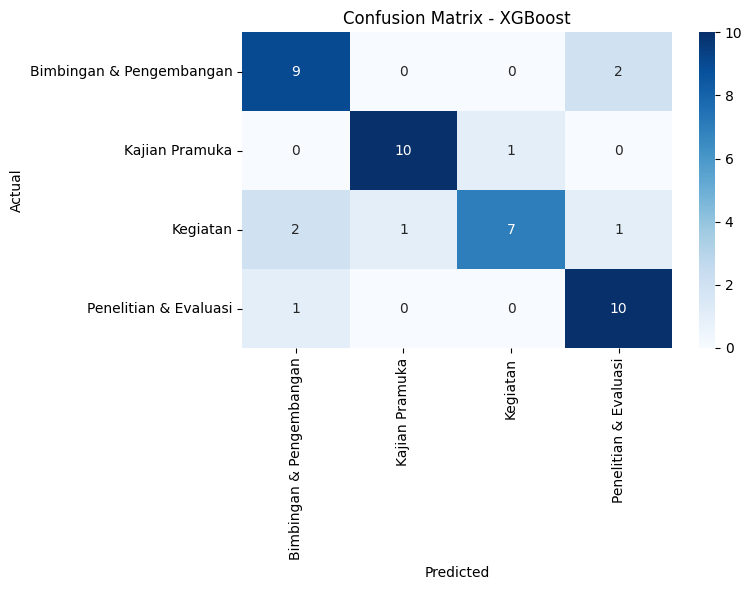

In [12]:
# ── Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names
)
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
 

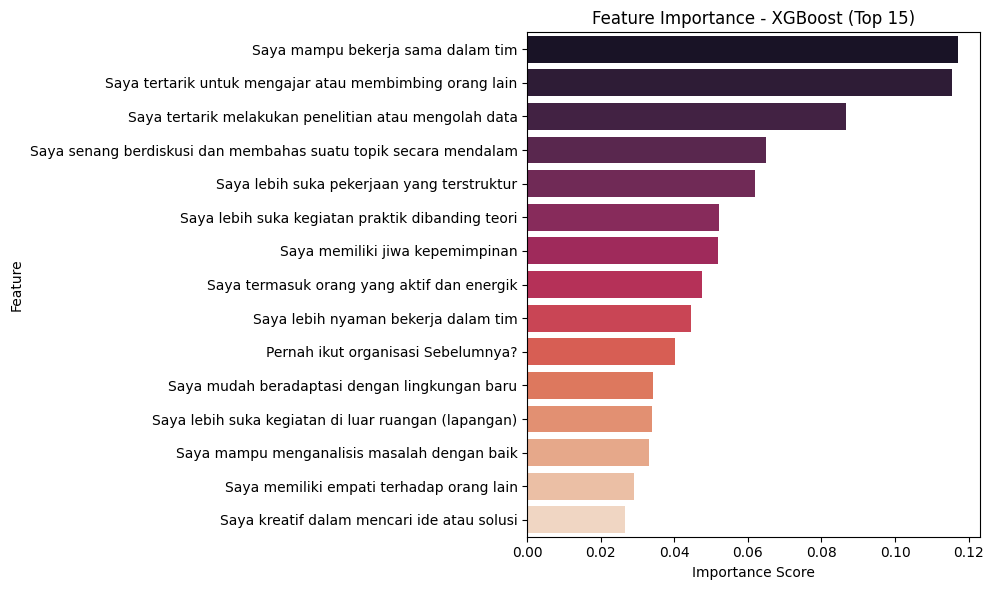

In [13]:
# ── Feature Importance ──────────────────────────────────────────
importances = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)
top_n = min(15, len(importances))
 
plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances.values[:top_n],
    y=importances.index[:top_n],
    palette='rocket'
)
plt.title(f'Feature Importance - XGBoost (Top {top_n})')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [15]:
# ── Simpan Model Artifacts (SATU FILE untuk app.py) ─────────────
# Hapus file lama kalau ada, supaya tidak terbaca yang versi lama
import os
for f in ['model_xgboost.pkl', 'encoders.pkl']:
    if os.path.exists(f):
        os.remove(f)
        print(f"File lama dihapus: {f}")
 
artifacts = {
    'model':        model,
    'encoders':     encoders,
    'fitur_kolom':  feature_cols,
    'target_col':   TARGET,
}
 
with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
 
# Verifikasi isi artifacts
with open('model_artifacts.pkl', 'rb') as f:
    check = pickle.load(f)
 
print("\n✅ model_artifacts.pkl berhasil disimpan")
print(f"   Model     : {type(check['model']).__name__}")
print(f"   Encoders  : {list(check['encoders'].keys())}")
print(f"   Fitur     : {check['fitur_kolom']}")
print(f"   Target    : {check['target_col']}")


✅ model_artifacts.pkl berhasil disimpan
   Model     : XGBClassifier
   Encoders  : ['Status', 'Jenis Kelamin', 'Pernah ikut organisasi Sebelumnya?', 'Pernah jadi panitia?', 'Pernah jadi leader?', 'Pernah ikut penelitian/evaluasi kegiatan?', 'Saya lebih suka bekerja di:', 'Saya lebih tertarik pada:', 'Divisi yang paling di minati?']
   Fitur     : ['Status', 'Jenis Kelamin', 'Saya lebih suka kegiatan di luar ruangan (lapangan)', 'Saya senang berdiskusi dan membahas suatu topik secara mendalam', 'Saya tertarik untuk mengajar atau membimbing orang lain', 'Saya tertarik melakukan penelitian atau mengolah data', 'Saya lebih suka kegiatan praktik dibanding teori', 'Saya memiliki kemampuan komunikasi yang baik', 'Saya mampu bekerja sama dalam tim', 'Saya memiliki jiwa kepemimpinan', 'Saya mampu menganalisis masalah dengan baik', 'Saya teliti dalam mengerjakan sesuatu', 'Saya kreatif dalam mencari ide atau solusi', 'Saya termasuk orang yang aktif dan energik', 'Saya lebih nyaman bekerja dala